Consider the bivariate distribution with PDF:

$p(x_{1},x_{2})=\frac{1}{2\pi\sqrt{1-\rho^{2}}}\exp\left\{-\frac{1}{2(1-\rho^{2})}(x_{1}^{2}+x_{2}^{2}-2\rho x_{1}x_{2})\right\}$

with $\rho\in[-1,1]$.

1.  Which distribution do you recognize?
2.  Derive the conditional distributions of each component, and implement the corresponding Gibbs sampler. <br> Represent in the plane the contours of the density target, and the evolution of the simulated Markov chain. <br> What happens when $\rho\to1$?
3.  Implement an RWHM algorithm (random walk Hastings-Metropolis) with a Gaussian proposal with variance $\sigma$. <br> Start with $\sigma =\tau I_{2}$, and try to see what happens for different values of $\tau$, especially when $\rho$ is close to $1$. <br> Then try with $\sigma$ proportional to the variance of the target distribution. Comment.

---

In [63]:
import numpy as np
import pandas as pd
import plotnine as pn
rng = np.random.default_rng(seed=12345)

def gibbs_sampler(x_01, x_02, N, rho):
    chain_1 = np.zeros(N)
    chain_1[0] = x_01

    chain_2 = np.zeros(N)
    chain_2[0] = x_02

    for i in range(1, N):
        chain_1[i] = rng.normal(rho * chain_2[i-1], 1-rho**2)
        chain_2[i] = rng.normal(rho * chain_1[i-1], 1-rho**2)
    
    df = pd.DataFrame(
        {"dim1": chain_1, "dim2": chain_2, "rho": rho}
    )
    return df

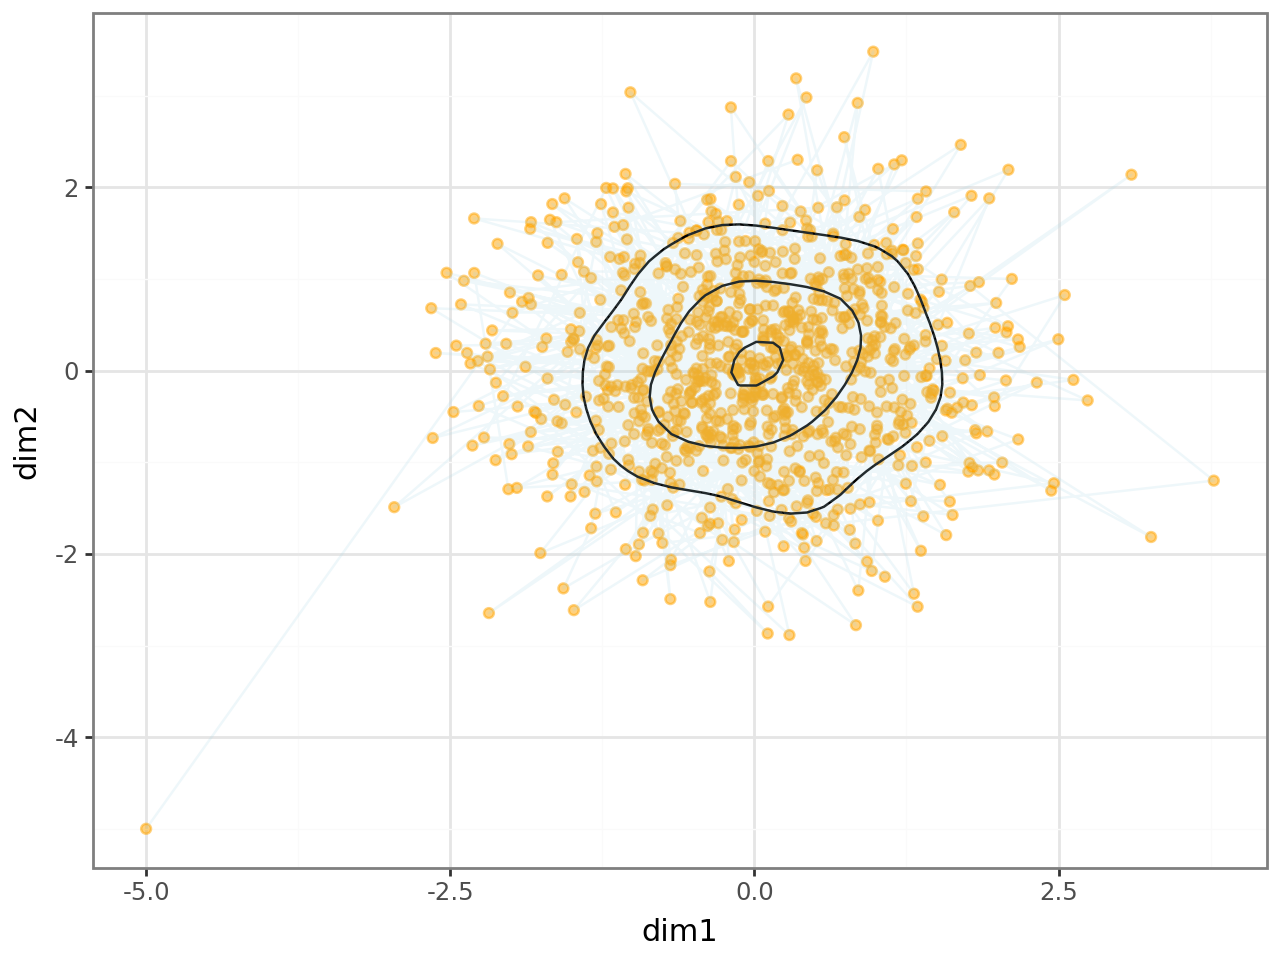

In [64]:
df = gibbs_sampler(-5, -5, 1000, 0.1)
(
    pn.ggplot(df, pn.aes(x = "dim1", y = "dim2")) +
    pn.geom_point(alpha = 0.5, color = "orange") +
    pn.geom_density_2d() +
    pn.geom_path(alpha = 0.2, color = "lightblue") +
    pn.theme_bw()
)

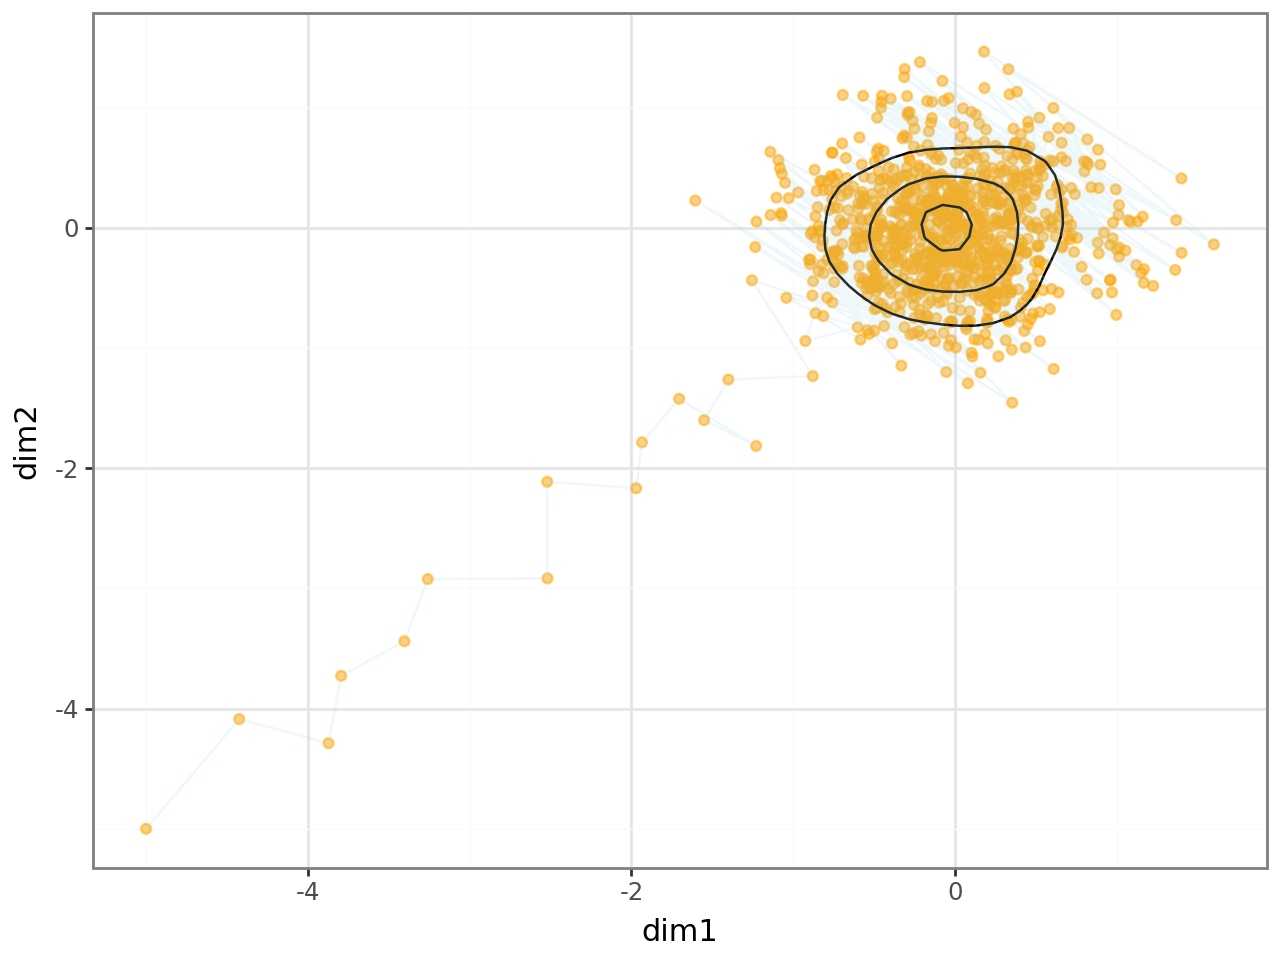

In [65]:
df = gibbs_sampler(-5, -5, 1000, 0.9)
(
    pn.ggplot(df, pn.aes(x = "dim1", y = "dim2")) +
    pn.geom_point(alpha = 0.5, color = "orange") +
    pn.geom_density_2d() +
    pn.geom_path(alpha = 0.2, color = "lightblue") +
    pn.theme_bw()
)

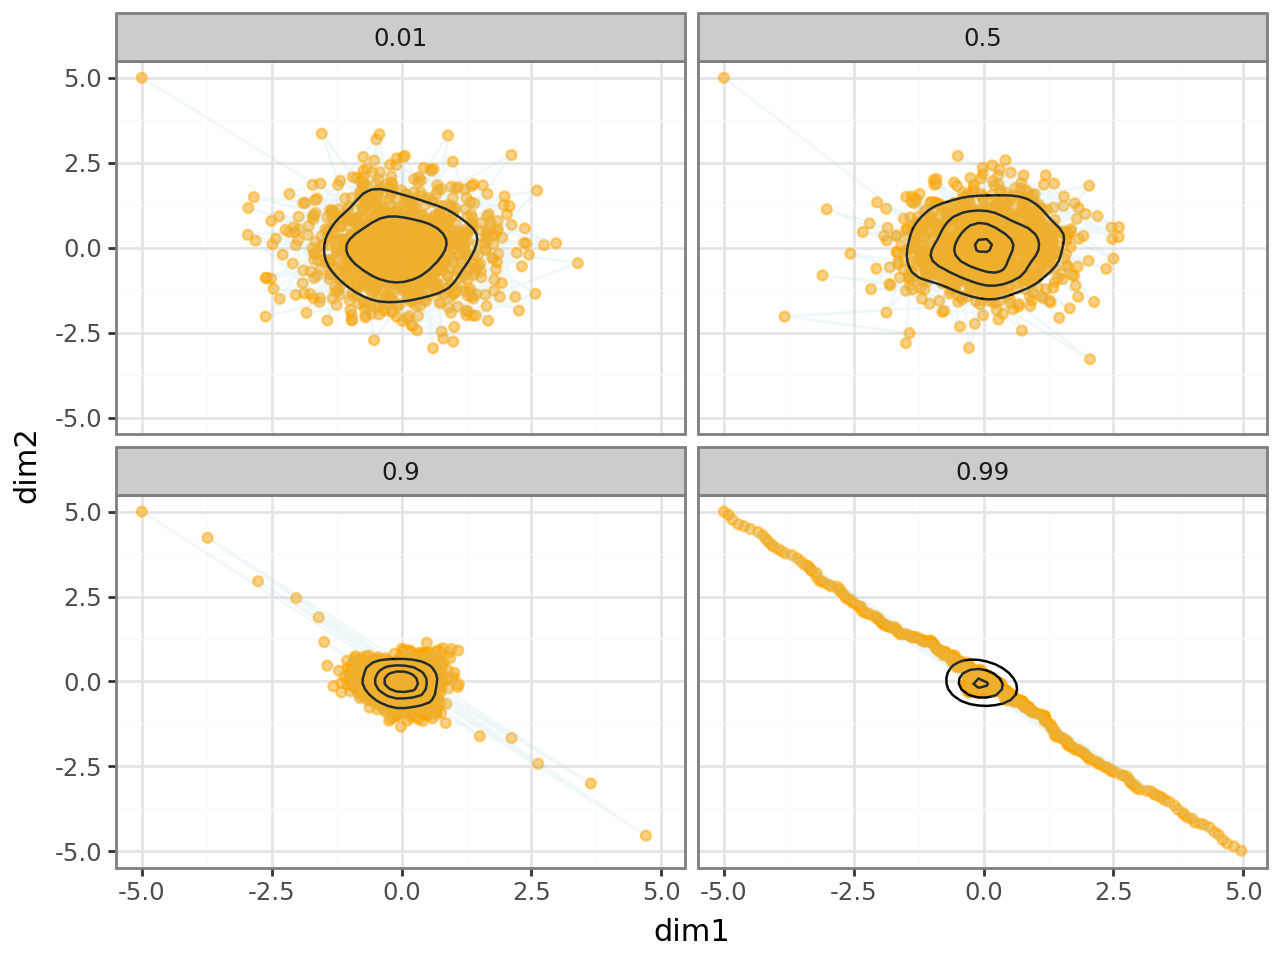

In [70]:
df_ = pd.concat(
    [gibbs_sampler(-5, 5, 1000, 0.01),
    gibbs_sampler(-5, 5, 1000, 0.5),
    gibbs_sampler(-5, 5, 1000, 0.9),
    gibbs_sampler(-5, 5, 1000, 0.99)]
)
(
    pn.ggplot(df_, pn.aes(x = "dim1", y = "dim2")) +
    pn.geom_point(alpha = 0.5, color = "orange") +
    pn.geom_density_2d() +
    pn.geom_path(alpha = 0.2, color = "lightblue") +
    pn.theme_bw() +
    pn.facet_wrap("rho")
)